# ResNet-50 Inference & Grad-CAM Visualization

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import models, transforms
from torch.utils.data import DataLoader
from PIL import Image
import cv2
import pickle
from tqdm import tqdm

In [2]:
def apply_clahe(img, **kwargs):
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) for retinal enhancement."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return enhanced_img

def circular_crop(img, **kwargs):
    """Apply circular crop to focus on the retina region."""
    height, width, _ = img.shape
    center = (int(width/2), int(height/2))
    radius = min(center[0], center[1], width - center[0], height - center[1])

    Y, X = np.ogrid[:height, :width]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    mask = dist_from_center <= radius
    cropped = np.zeros_like(img)
    cropped[mask] = img[mask]

    cropped = cv2.resize(cropped, (224, 224))
    return cropped    
# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Reload Datasets and Model

In [3]:
# Redefine helper functions/classes required for loading
class APTOSDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.loc[idx, 'id_code']
        label = int(self.dataframe.loc[idx, 'diagnosis'])
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        image = np.array(Image.open(img_path).convert('RGB'))
        if self.transform:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)


# Re-load dataloaders from pickle
with open("../data/processed/loaders.pkl", "rb") as f:
    data_objects = pickle.load(f)

val_loader = data_objects["val_loader"]


## Load Trained Model Checkpoint

In [4]:
model_path = "../models/best_resnet50.pth"
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 5)

state_dict = torch.load(model_path, map_location=device)
new_state_dict = {}
for k, v in state_dict.items():
    new_k = k.replace("module.", "")  
    new_state_dict[new_k] = v

model.load_state_dict(new_state_dict)
model = model.to(device)
model.eval()

print("Model loaded successfully.")



Model loaded successfully.


## Run Inference on Validation Set

Running Inference: 100%|██████████| 23/23 [00:41<00:00,  1.81s/it]


===== ResNet-50 Metrics =====
Accuracy:            0.7271
Precision (macro):   0.5667
Recall (macro):      0.5938
F1-score (macro):    0.5659
Balanced Accuracy:   0.5938

Classification Report:

              precision    recall  f1-score   support

           0     0.9454    0.9584    0.9519       361
           1     0.3909    0.5811    0.4674        74
           2     0.7519    0.4850    0.5897       200
           3     0.2537    0.4359    0.3208        39
           4     0.4918    0.5085    0.5000        59

    accuracy                         0.7271       733
   macro avg     0.5667    0.5938    0.5659       733
weighted avg     0.7633    0.7271    0.7342       733



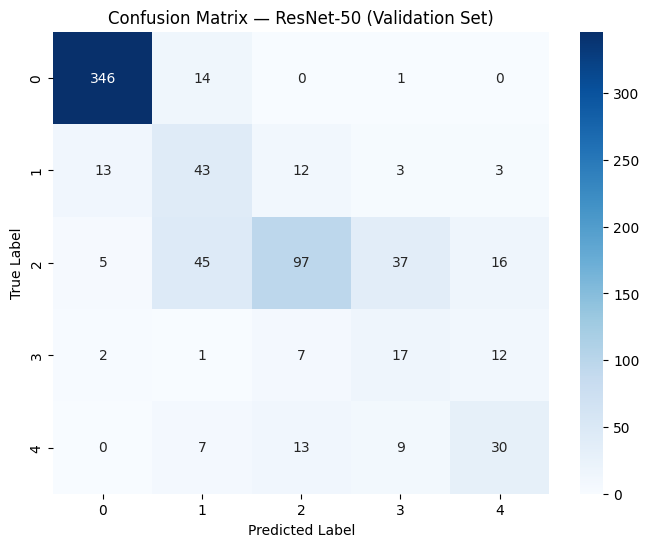

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ------------------------------
# Run Inference
# ------------------------------
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Running Inference"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ------------------------------
# Metrics
# ------------------------------
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')
bacc = balanced_accuracy_score(y_true, y_pred)

print("===== ResNet-50 Metrics =====")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec:.4f}")
print(f"Recall (macro):      {rec:.4f}")
print(f"F1-score (macro):    {f1:.4f}")
print(f"Balanced Accuracy:   {bacc:.4f}")
print("=====================================\n")

# Full Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — ResNet-50 (Validation Set)")
plt.show()

## Grad-CAM Visualization

🩺 Grad-CAM for Image: e6a6acf7fca1


/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


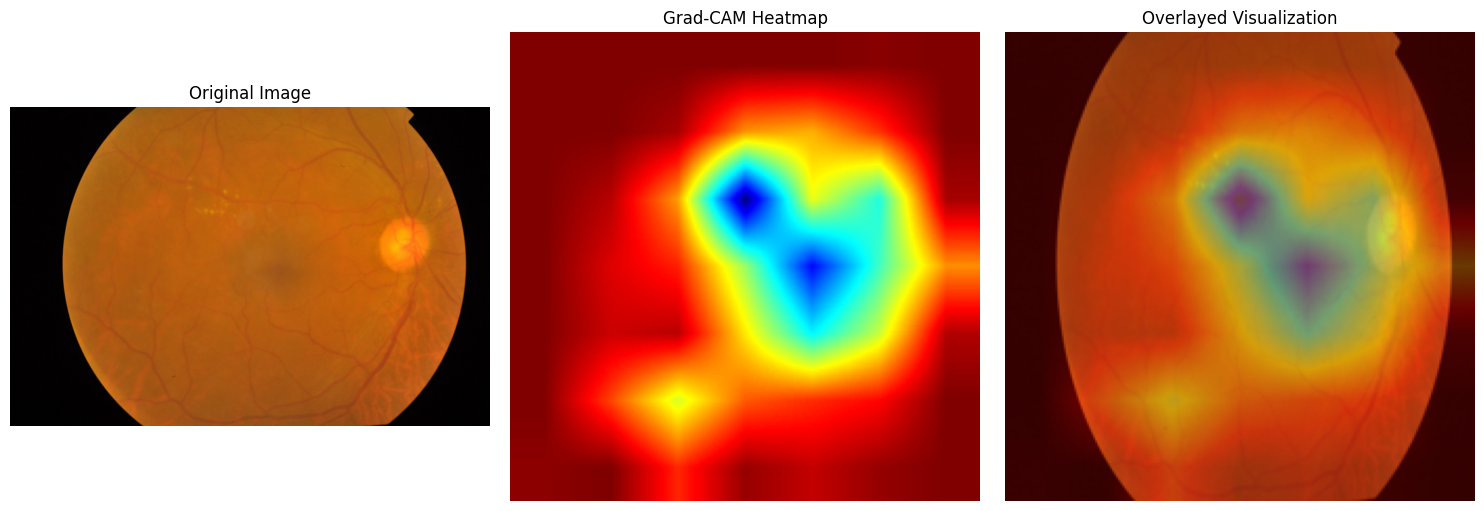

🩺 Grad-CAM for Image: 61ac9b0dc6b9


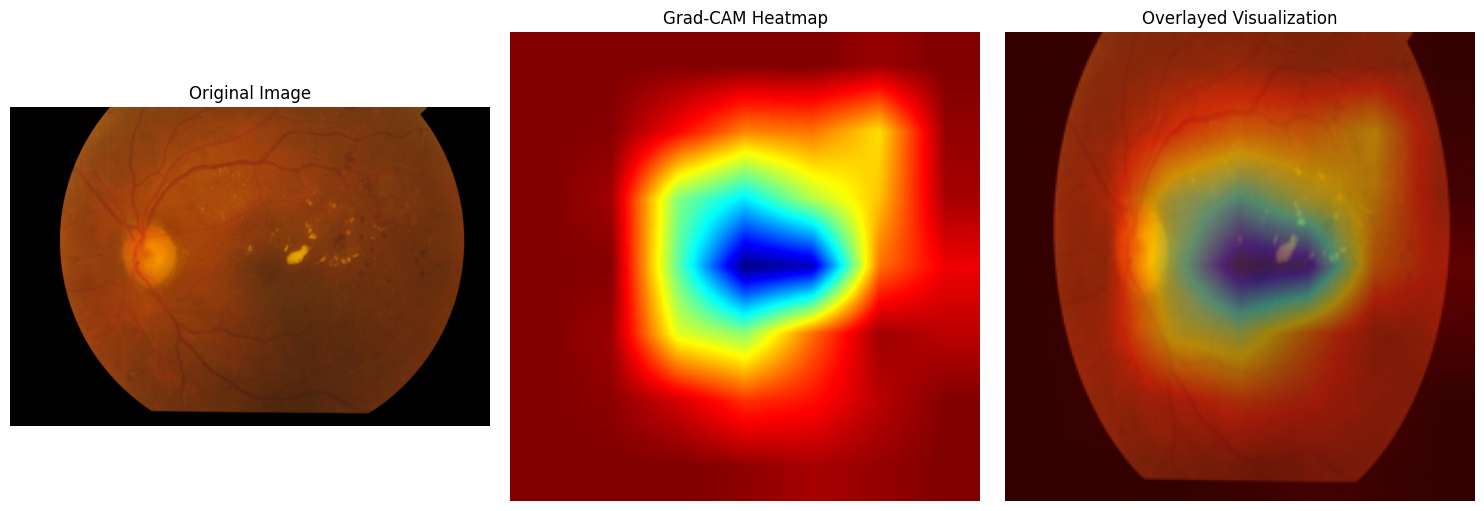

🩺 Grad-CAM for Image: 74eee788edee


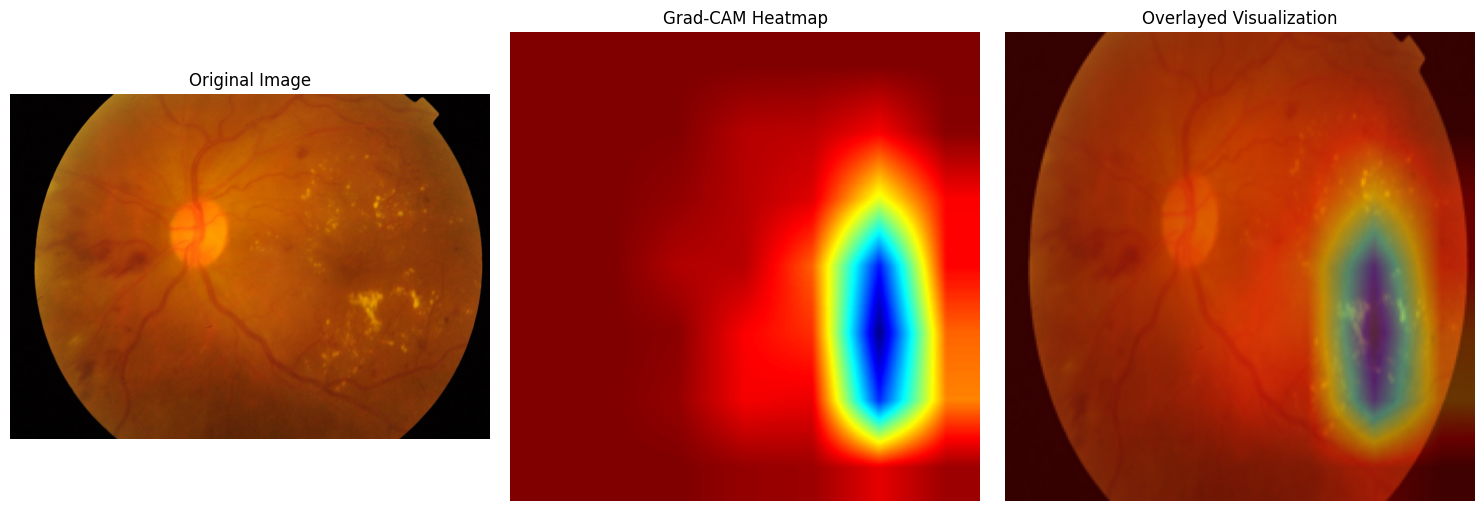

In [7]:
# GradCAM helper class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_image, target_class=None):
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1)
        loss = output[:, target_class]
        self.model.zero_grad()
        loss.backward(retain_graph=True)

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(len(pooled_gradients)):
            activations[i, :, :] *= pooled_gradients[i]
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= np.max(heatmap)
        return heatmap

# Initialize GradCAM with the last convolutional layer
gradcam = GradCAM(model, model.layer4[-1])


# Visualize Grad-CAM for Sample Images
def show_gradcam(image_path, model, gradcam, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(target_size)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                             std=[0.229,0.224,0.225])
    ])
    input_tensor = transform(img_resized).unsqueeze(0).to(device)
    heatmap = gradcam.generate_heatmap(input_tensor)
    heatmap = cv2.resize(heatmap, target_size)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img_cv = np.array(img_resized)
    overlay = cv2.addWeighted(img_cv, 0.6, heatmap, 0.4, 0)

    fig, ax = plt.subplots(1, 3, figsize=(15,5))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[1].imshow(heatmap)
    ax[1].set_title("Grad-CAM Heatmap")
    ax[2].imshow(overlay)
    ax[2].set_title("Overlayed Visualization")
    for a in ax: a.axis('off')
    plt.tight_layout()
    plt.show()


# Recreate val_df for visualization
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("../data/raw/train.csv")
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['diagnosis'], random_state=42)

sample_images = val_df.sample(3, random_state=42)['id_code'].values
image_dir = "../data/raw/train_images/"

for img_id in sample_images:
    print(f"Grad-CAM for Image: {img_id}")
    show_gradcam(os.path.join(image_dir, f"{img_id}.png"), model, gradcam)